# Day 12 – Feature Engineering for Market Prediction (EURUSD)

## Objective
Create predictive features from historical EURUSD data to support future machine learning and quantitative modeling.

## Goal
Transform raw market data into structured signals that may improve predictive power.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#Create Output Folder
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [3]:
#Load Dataset
file_path = r"C:\Users\THIS PC\Desktop\quant-finance-portfolio\day-01-market-data-analysis\data\eurusd_daily_raw.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,open,high,low,close,simple_return,log_return,cum_return,equity_curve,rolling_peak,drawdown
2007-01-17,1.2917,1.2950,1.2898,1.2938,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-18,1.2938,1.2976,1.2896,1.2963,0.001932,0.001930,0.001932,1.001932,1.001932,0.000000
2007-01-19,1.2963,1.3001,1.2914,1.2961,-0.000154,-0.000154,0.001778,1.001778,1.001932,-0.000154
2007-01-22,1.2959,1.2977,1.2923,1.2949,-0.000926,-0.000926,0.000850,1.000850,1.001932,-0.001080
2007-01-23,1.2949,1.3044,1.2929,1.3026,0.005946,0.005929,0.006802,1.006802,1.006802,0.000000


In [4]:
#Create Target Variable
df["target"] = np.where(df["simple_return"].shift(-1) > 0, 1, 0)

#Create Lag Features
df["return_lag_1"] = df["simple_return"].shift(1)
df["return_lag_2"] = df["simple_return"].shift(2)
df["return_lag_3"] = df["simple_return"].shift(3)
df["return_lag_5"] = df["simple_return"].shift(5)

#Rolling Statistics
df["rolling_mean_5"] = df["simple_return"].rolling(5).mean()
df["rolling_mean_10"] = df["simple_return"].rolling(10).mean()

df["rolling_std_5"] = df["simple_return"].rolling(5).std()
df["rolling_std_10"] = df["simple_return"].rolling(10).std()

In [5]:
#Momentum Features
df["momentum_3"] = df["close"] / df["close"].shift(3) - 1
df["momentum_5"] = df["close"] / df["close"].shift(5) - 1
df["momentum_10"] = df["close"] / df["close"].shift(10) - 1

In [6]:
#Price Range Features
df["high_low_range"] = (df["high"] - df["low"]) / df["close"]
df["open_close_range"] = (df["close"] - df["open"]) / df["open"]

In [7]:
#Technical Indicator features
#SMA
df["SMA_10"] = df["close"].rolling(10).mean()
df["SMA_20"] = df["close"].rolling(20).mean()

df["SMA_ratio"] = df["SMA_10"] / df["SMA_20"]

#RSI
delta = df["close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

#MACD
df["EMA_12"] = df["close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]

In [8]:
#Clean Dataset
feature_df = df.dropna().copy()
feature_df.head()

,open,high,low,close,simple_return,log_return,cum_return,equity_curve,rolling_peak,drawdown,...,momentum_10,high_low_range,open_close_range,SMA_10,SMA_20,SMA_ratio,RSI_14,EMA_12,EMA_26,MACD
2007-02-13,1.2966,1.3043,1.2954,1.3037,0.005476,0.005461,0.007652,1.007652,1.007884,-0.000230,...,0.005243,0.006827,0.005476,1.29986,1.297825,1.001568,56.261682,1.299260,1.297600,0.001660
2007-02-14,1.3038,1.3149,1.3024,1.3129,0.007057,0.007032,0.014763,1.014763,1.014763,0.000000,...,0.007366,0.009521,0.006980,1.30082,1.298780,1.001571,66.836735,1.301358,1.298733,0.002625
2007-02-15,1.3129,1.3171,1.3118,1.3140,0.000838,0.000837,0.015613,1.015613,1.015613,0.000000,...,0.009139,0.004033,0.000838,1.30201,1.299665,1.001804,69.296741,1.303303,1.299864,0.003439
2007-02-16,1.3140,1.3146,1.3094,1.3137,-0.000228,-0.000228,0.015381,1.015381,1.015613,-0.000228,...,0.013579,0.003958,-0.000228,1.30377,1.300545,1.002480,66.544118,1.304903,1.300889,0.004014
2007-02-19,1.3146,1.3163,1.3122,1.3155,0.001370,0.001369,0.016772,1.016772,1.016772,0.000000,...,0.017559,0.003117,0.000685,1.30604,1.301575,1.003430,66.909091,1.306533,1.301971,0.004562


In [9]:
#Select Features Columns
feature_cols = [
    "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5",
    "rolling_mean_5", "rolling_mean_10",
    "rolling_std_5", "rolling_std_10",
    "momentum_3", "momentum_5", "momentum_10",
    "high_low_range", "open_close_range",
    "SMA_ratio", "RSI_14", "MACD"
]

In [11]:
#Create A modelling Dataset
model_data = feature_df[feature_cols + ["target", "simple_return", "close"]]
model_data.head()

,return_lag_1,return_lag_2,return_lag_3,return_lag_5,rolling_mean_5,rolling_mean_10,rolling_std_5,rolling_std_10,momentum_3,momentum_5,momentum_10,high_low_range,open_close_range,SMA_ratio,RSI_14,MACD,target,simple_return,close
2007-02-13,-0.002999,-0.002684,0.002152,0.004254,0.000836,0.000529,0.003616,0.003712,-0.000230,0.004159,0.005243,0.006827,0.005476,1.001568,56.261682,0.001660,1,0.005476,1.3037
2007-02-14,0.005476,-0.002999,-0.002684,0.002234,0.001800,0.000741,0.004594,0.004038,0.009535,0.008992,0.007366,0.009521,0.006980,1.001571,66.836735,0.002625,1,0.007057,1.3129
2007-02-15,0.007057,0.005476,-0.002999,0.002152,0.001538,0.000917,0.004606,0.003996,0.013420,0.007669,0.009139,0.004033,0.000838,1.001804,69.296741,0.003439,0,0.000838,1.3140
2007-02-16,0.000838,0.007057,0.005476,-0.002684,0.002029,0.001355,0.004152,0.003537,0.007670,0.010150,0.013579,0.003958,-0.000228,1.002480,66.544118,0.004014,1,-0.000228,1.3137
2007-02-19,-0.000228,0.000838,0.007057,-0.002999,0.002902,0.001747,0.003174,0.003263,0.001980,0.014577,0.017559,0.003117,0.000685,1.003430,66.909091,0.004562,0,0.001370,1.3155


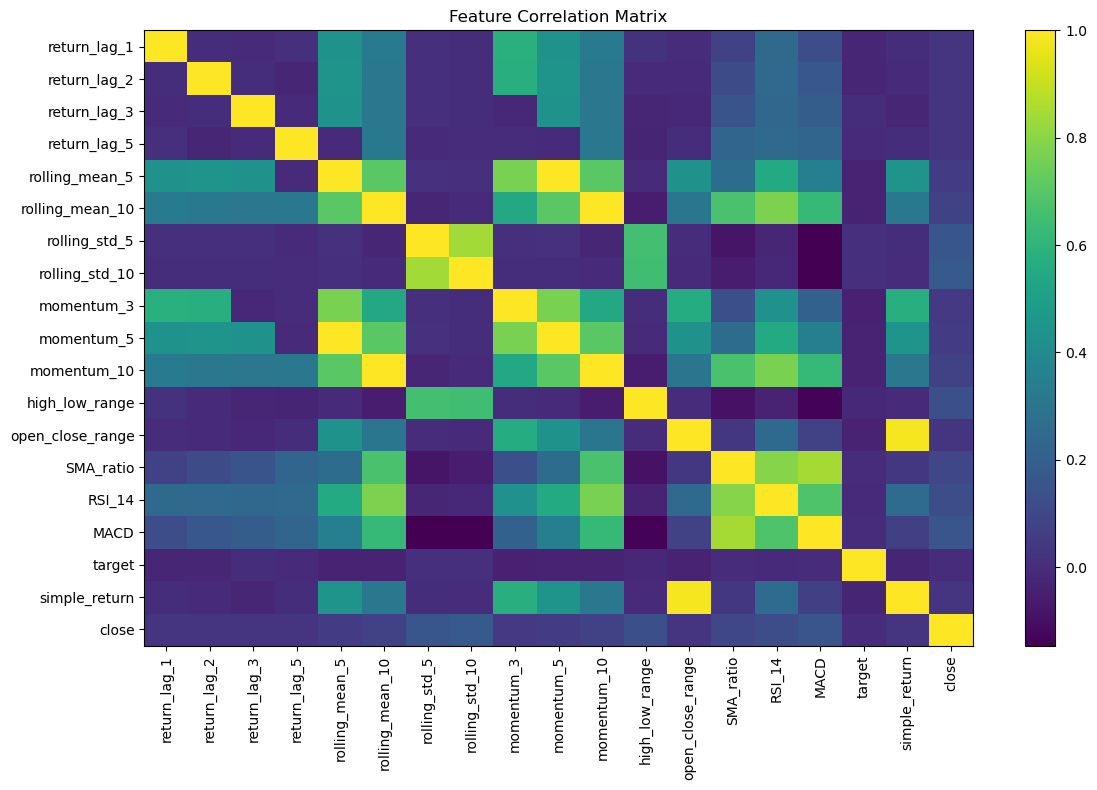

In [12]:
#Inspect Feature Correlation
corr = model_data.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("outputs/charts/day12_feature_correlation.png")
plt.show()

In [13]:
#Check Target Balance
target_counts = model_data["target"].value_counts()
print(target_counts)

target
1    2503
0    2478
Name: count, dtype: int64


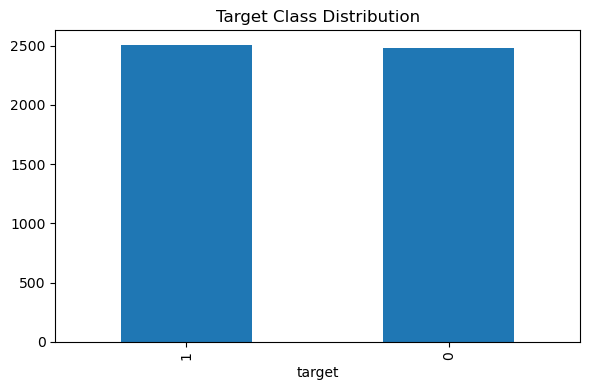

In [14]:
#Optional plot
target_counts.plot(kind="bar", figsize=(6, 4), title="Target Class Distribution")
plt.tight_layout()
plt.savefig("outputs/charts/day12_target_distribution.png")
plt.show()

In [15]:
#Saved Engineering Dataset
model_data.to_csv("outputs/tables/day12_feature_dataset.csv", index=True)

In [16]:
#Save feature summary:
feature_summary = pd.DataFrame({
    "Feature": feature_cols,
    "Description": [
        "Previous day's return",
        "Return from 2 days ago",
        "Return from 3 days ago",
        "Return from 5 days ago",
        "5-day average return",
        "10-day average return",
        "5-day return volatility",
        "10-day return volatility",
        "3-day price momentum",
        "5-day price momentum",
        "10-day price momentum",
        "Daily high-low trading range",
        "Open-to-close price movement",
        "Short vs long moving average ratio",
        "14-day RSI momentum indicator",
        "MACD momentum indicator"
    ]
})

feature_summary.to_csv("outputs/tables/day12_feature_summary.csv", index=False)
feature_summary

,Feature,Description
0,return_lag_1,Previous day's return
1,return_lag_2,Return from 2 days ago
2,return_lag_3,Return from 3 days ago
3,return_lag_5,Return from 5 days ago
4,rolling_mean_5,5-day average return
5,rolling_mean_10,10-day average return
6,rolling_std_5,5-day return volatility
7,rolling_std_10,10-day return volatility
8,momentum_3,3-day price momentum
9,momentum_5,5-day price momentum


## Analyst Interpretation

This project focuses on transforming raw EURUSD market data into a richer set of features that can be used for predictive modeling.

Rather than relying only on price or a single indicator, the engineered dataset captures multiple dimensions of market behavior, including recent returns, momentum, volatility, and intraday price structure.

The lag features help represent short-term memory in the market by showing what happened in previous periods. Rolling averages and volatility features summarize recent trend and risk conditions. Momentum features measure how strongly price has been moving across different horizons, while price range variables reflect the structure of daily trading activity.

The correlation matrix helps evaluate how these features relate to each other and whether some carry overlapping information. The target distribution also provides an early indication of whether the prediction problem is balanced or skewed.

Overall, this project creates a stronger analytical foundation for machine learning. It shows that predictive modeling in finance is not just about choosing an algorithm, but about carefully constructing the inputs used by the model.